# 1. Preprocessing

## a. Data load and check
Memeriksa informasi-informasi awal dari data

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [68]:
df = pd.DataFrame(pd.read_csv("Student_Mental_health.csv"))
df

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    str    
 1   Choose your gender                            101 non-null    str    
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    str    
 4   Your current year of Study                    101 non-null    str    
 5   What is your CGPA?                            101 non-null    str    
 6   Marital status                                101 non-null    str    
 7   Do you have Depression?                       101 non-null    str    
 8   Do you have Anxiety?                          101 non-null    str    
 9   Do you have Panic attack?                     101 non-null    str    
 10  D

In [70]:
df.duplicated().sum()

np.int64(0)

## b. Data Cleaning
Isinya bersih bersih data, kaya hapus data ga penting, fill data NaN

In [71]:
df.columns = ['Timestamp','Gender','Age','Course','Year','CGPA',
              'Marital','Depression','Anxiety','Panic','Treatment']
df['Course'] = df['Course'].str.strip()

In [72]:
df.drop("Timestamp", axis=1, inplace=True)
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment
0,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


In [73]:
df["Gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [74]:
df['Year'] = df['Year'].str.replace('year', '', case=False).str.strip().astype(int)

In [75]:
# cari baris NaN pada  Age
df[df['Age'].isna()]

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment
43,Male,NaN,BIT,1,0 - 1.99,No,No,No,No,No


In [76]:
print(df[df["Year"] == 1]["Age"].median())
df['Age'] = df['Age'].fillna(df[df["Year"] == 1]["Age"].median())

19.0


In [77]:
print(df.isna().sum())

Gender        0
Age           0
Course        0
Year          0
CGPA          0
Marital       0
Depression    0
Anxiety       0
Panic         0
Treatment     0
dtype: int64


In [78]:
df['CGPA'].unique()

<StringArray>
[ '3.00 - 3.49',  '3.50 - 4.00', '3.50 - 4.00 ',  '2.50 - 2.99',
  '2.00 - 2.49',     '0 - 1.99']
Length: 6, dtype: str

In [79]:
df['CGPA'] = df['CGPA'].str.strip()
df['CGPA'].unique()

<StringArray>
['3.00 - 3.49', '3.50 - 4.00', '2.50 - 2.99', '2.00 - 2.49', '0 - 1.99']
Length: 5, dtype: str

## c. EDA
Liat liat dulu statistik datanya

In [80]:
sns.set_theme(style="whitegrid")
MENTAL_COLS = ['Depression', 'Anxiety', 'Panic']

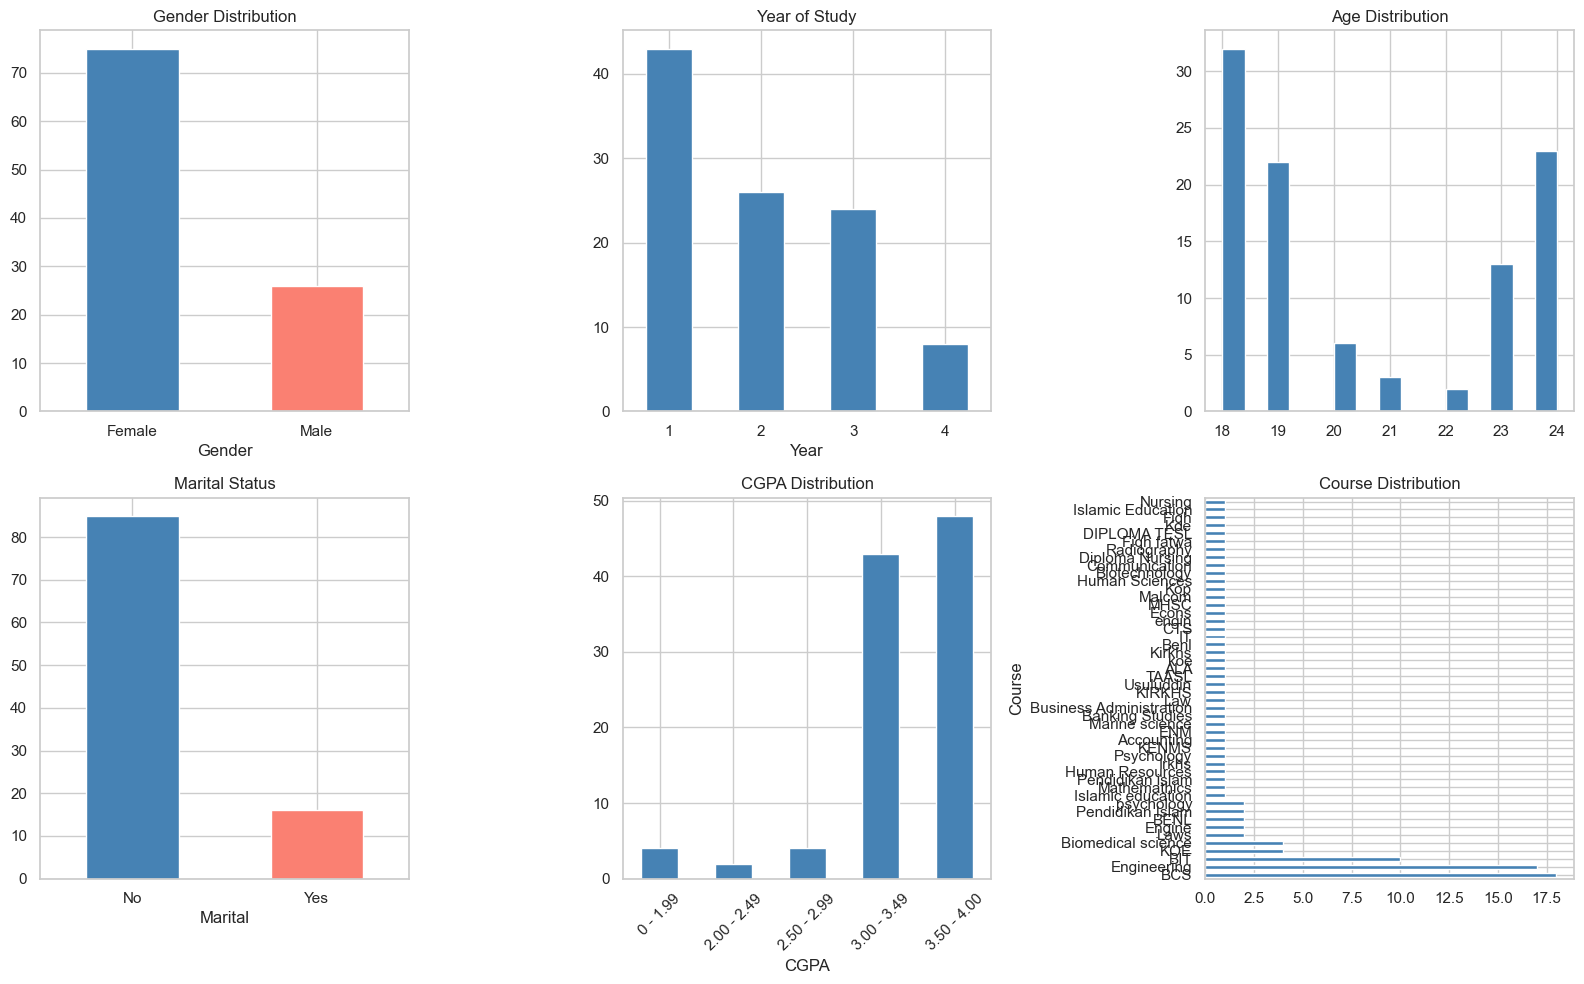

In [81]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Gender
df['Gender'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','salmon'])
axes[0,0].set_title('Gender Distribution')
axes[0,0].tick_params(axis='x', rotation=0)

# Year
df['Year'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Year of Study')
axes[0,1].tick_params(axis='x', rotation=0)

# Age
axes[0,2].hist(df['Age'], bins=15, color='steelblue', edgecolor='white')
axes[0,2].set_title('Age Distribution')

# Marital Status
df['Marital'].value_counts().plot(kind='bar', ax=axes[1,0], color=['steelblue','salmon'])
axes[1,0].set_title('Marital Status')
axes[1,0].tick_params(axis='x', rotation=0)

# CGPA
df['CGPA'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('CGPA Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

# Course
df['Course'].value_counts().plot(kind='barh', ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Course Distribution')

plt.tight_layout()
plt.show()

Insights:
- Female jauh lebih banyak yang ngisi. Ada kemungkinan modelnya bias dan lebih apal pola female.
- Mahasiswa tahun awal lebih sering ngisi.
- Pola age bentuknya kaya parabola, gede di awal dan akhir, di tengah dikit.
- Dikit banget yang nikah. Bisa dilihat nanti apakah yang nikah memiliki relation yang kuat ke kondisi tertentu.
- CGPA banyak yang di atas 3.00. Sedikit yang ada di bawah 2.99, memungkinkan untuk binning.
- Course terlalu sparse, cluttered banget, asli. Nanti di grouping dah mending.

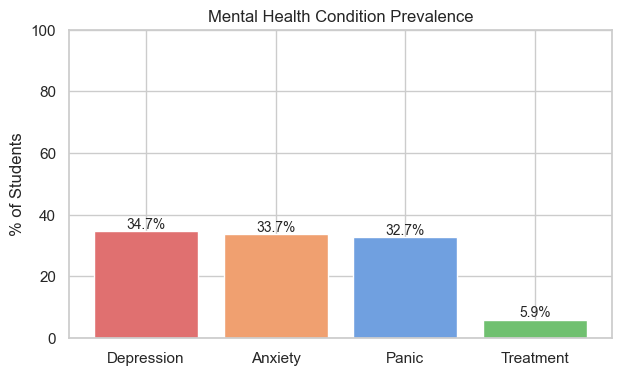

In [82]:
prevalence = df[MENTAL_COLS + ['Treatment']].apply(lambda col: (col == 'Yes').mean() * 100)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(prevalence.index, prevalence.values, color=['#e07070','#f0a070','#70a0e0','#70c070'])
ax.set_ylabel('% of Students')
ax.set_title('Mental Health Condition Prevalence')
ax.set_ylim(0, 100)

for bar, val in zip(bars, prevalence.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10)

plt.show()

Lumayan rata, dan yang treatment dikit, menarik. Bisa diolah nanti

In [83]:
mental_binary = df[MENTAL_COLS].apply(lambda col: (col == 'Yes').astype(int))
combos = mental_binary.groupby(MENTAL_COLS).size().reset_index(name='Count').sort_values('Count', ascending=False)
print(combos.to_string(index=False))

 Depression  Anxiety  Panic  Count
          0        0      0     37
          0        0      1     13
          0        1      0     13
          1        0      0     10
          1        1      1     10
          1        1      0      8
          1        0      1      7
          0        1      1      3


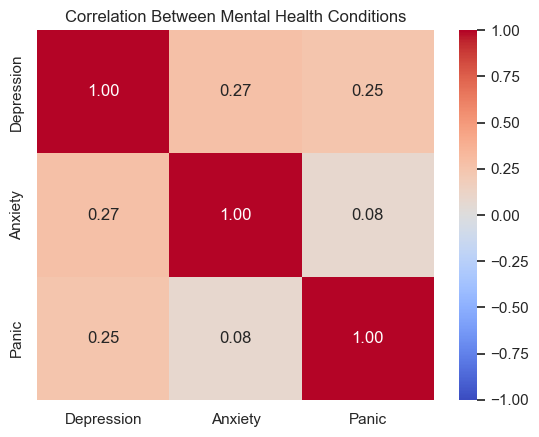

In [84]:
corr = mental_binary.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Mental Health Conditions')
plt.show()

Menarik, ga terlalu ada keterkaitan mutlak satu sama lain, mungkin nanti bisa diambil insightnya.

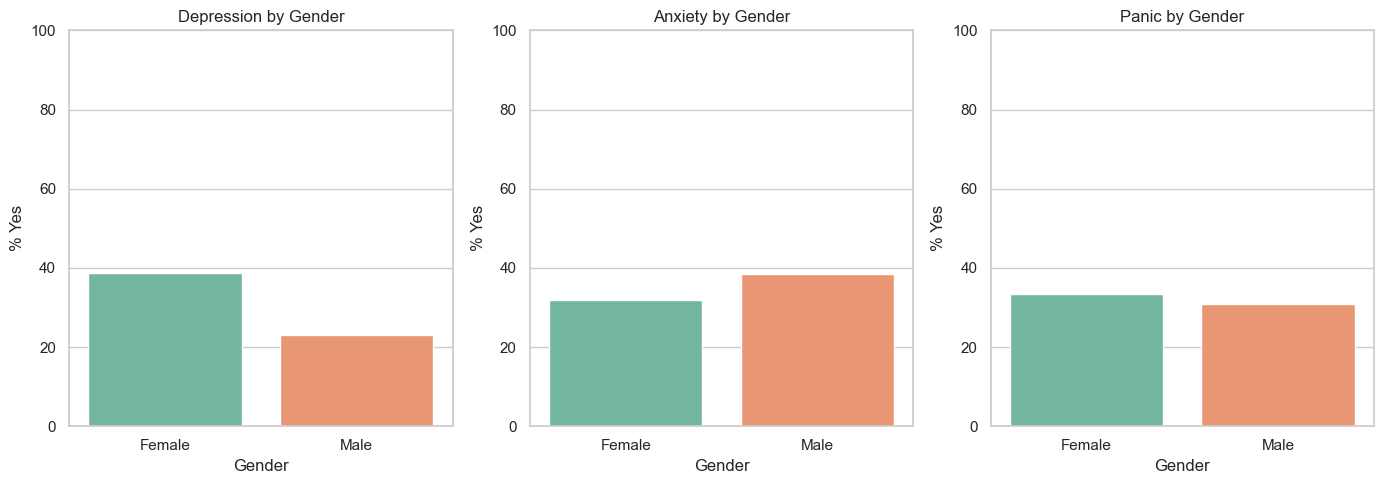

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Gender')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Gender', 'Pct']
    sns.barplot(data=ct, x='Gender', y='Pct', ax=ax, palette='Set2')
    ax.set_title(f'{col} by Gender')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Tidak ada dominasi atau kecenderungan mutlak dari gender terhadap keadaan mental.

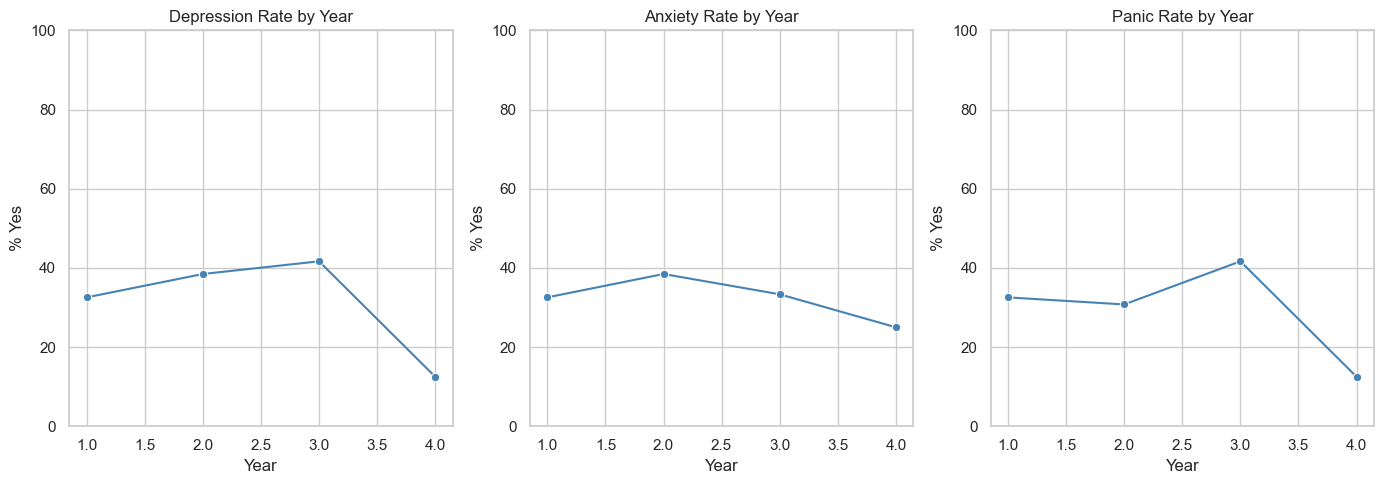

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Year')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Year', 'Pct']
    sns.lineplot(data=ct, x='Year', y='Pct', ax=ax, marker='o', color='steelblue')
    ax.set_title(f'{col} Rate by Year')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Terlihat depresi dan panic rate paling tinggi ada di tahun ke 3, dan anxiety di tahun ke 2.

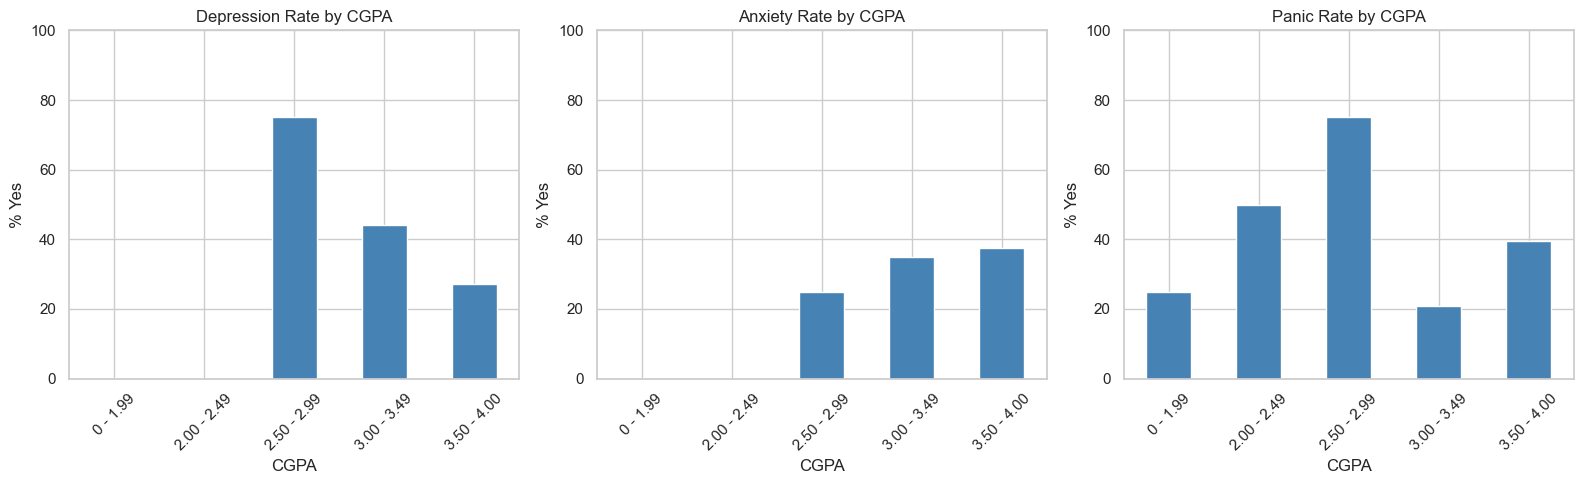

In [87]:
cgpa_order = sorted(df['CGPA'].unique())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('CGPA')[col].apply(lambda x: (x == 'Yes').mean() * 100).reindex(cgpa_order)
    ct.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{col} Rate by CGPA')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Tren dari setiap kondisi mental berbeda-beda jika dilihat berdasarkan CGPA. Depression rate memiliki tren yang
menurun mulai dari 2.5. Anxiety memiliki tren naik. Panic rate tidak terlalu memiliki tren yang jelas,
namun mahasiswa dengan CGPA yang rendah memiliki kondisi Panic.

In [88]:
df['Any_condition'] = df[MENTAL_COLS].apply(lambda row: 'Yes' in row.values, axis=1)

ct = pd.crosstab(df['Any_condition'], df['Treatment'])
ct.index = ['No Condition', 'Has Condition']
ct.columns = ['No Treatment', 'Seeking Treatment']
print(ct)
print()
print("Of students WITH a condition, % seeking treatment:",
      round(ct.loc['Has Condition', 'Seeking Treatment'] / ct.loc['Has Condition'].sum() * 100, 1), "%")

               No Treatment  Seeking Treatment
No Condition             37                  0
Has Condition            58                  6

Of students WITH a condition, % seeking treatment: 9.4 %


Uih, SANGAT sedikit mahasiswa dengan setidaknya satu kondisi mental yang mencari pertolongan profesional

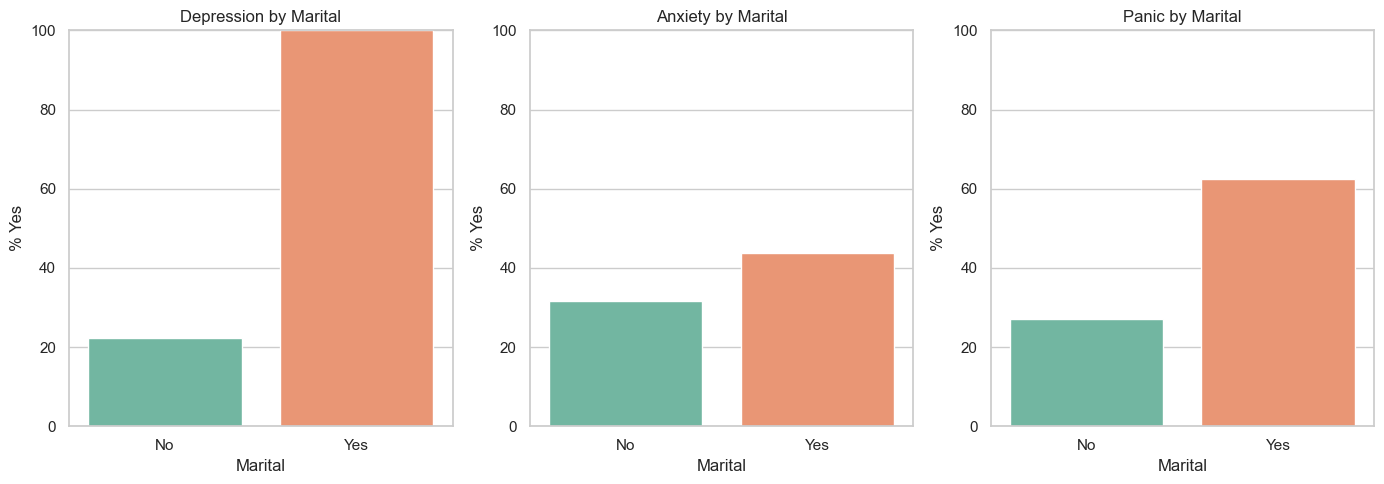

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Marital')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Marital', 'Pct']
    sns.barplot(data=ct, x='Marital', y='Pct', ax=ax, palette='Set2')
    ax.set_title(f'{col} by Marital')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [90]:
df[df["Marital"] == "Yes"]

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment,Any_condition
3,Female,22.0,Laws,3,3.00 - 3.49,Yes,Yes,No,No,No,True
6,Female,23.0,Pendidikan islam,2,3.50 - 4.00,Yes,Yes,No,Yes,No,True
11,Female,24.0,Engineering,3,3.50 - 4.00,Yes,Yes,No,No,No,True
17,Female,24.0,ENM,4,3.00 - 3.49,Yes,Yes,Yes,Yes,No,True
19,Female,18.0,Marine science,2,3.50 - 4.00,Yes,Yes,Yes,Yes,No,True
27,Male,18.0,Engineering,2,3.00 - 3.49,Yes,Yes,Yes,No,No,True
28,Female,24.0,BIT,3,3.50 - 4.00,Yes,Yes,Yes,Yes,Yes,True
33,Male,18.0,BCS,2,3.50 - 4.00,Yes,Yes,Yes,No,Yes,True
39,Female,24.0,Engineering,2,2.50 - 2.99,Yes,Yes,No,Yes,Yes,True
50,Female,23.0,ALA,1,2.50 - 2.99,Yes,Yes,No,Yes,Yes,True


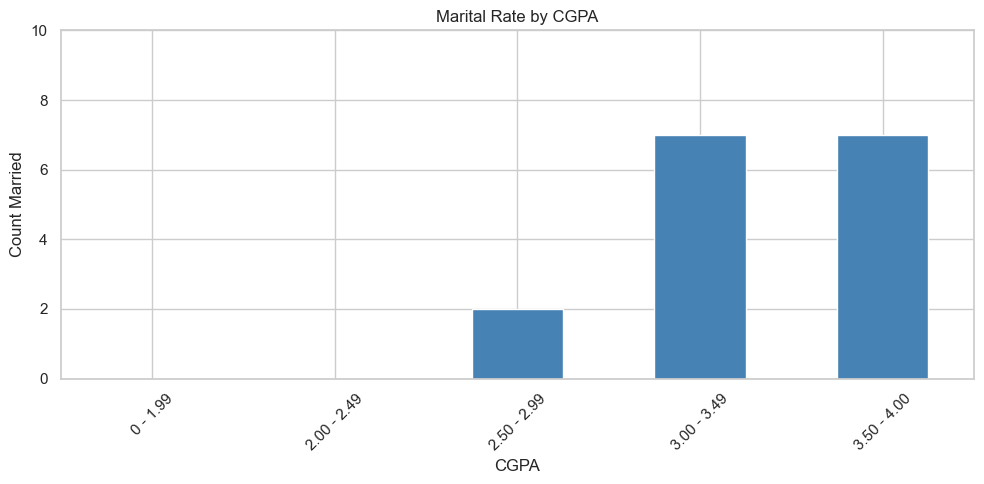

In [91]:
cgpa_order = sorted(df['CGPA'].unique())

fig, ax = plt.subplots(figsize=(10, 5))
ct = (df.groupby('CGPA')['Marital'].apply(lambda x: (x == 'Yes').sum()).reindex(cgpa_order))
ct.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Marital Rate by CGPA')
ax.set_ylabel('Count Married')
ax.set_xlabel('CGPA')
ax.set_ylim(0, 10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

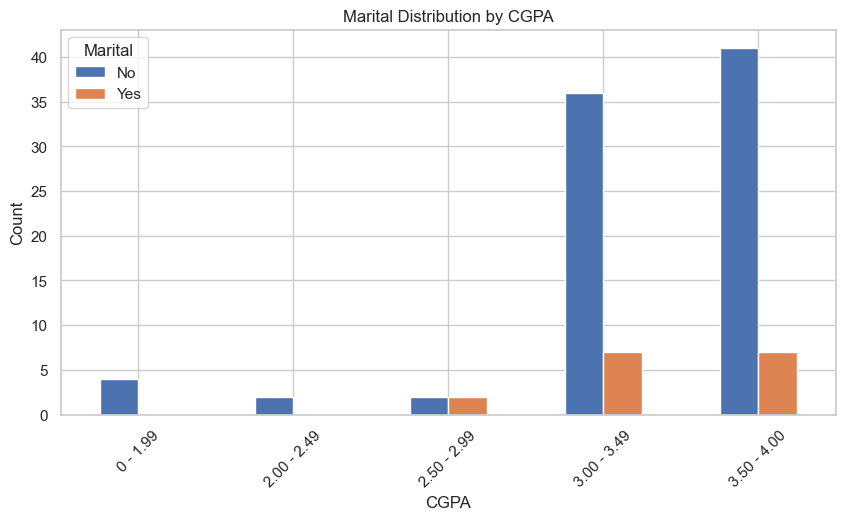

In [92]:
pd.crosstab(df['CGPA'], df['Marital']).reindex(cgpa_order).plot(kind='bar', figsize=(10,5))
plt.title('Marital Distribution by CGPA')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Dari sini, kita bisa lihat bahwa orang yang menikah berada di rentang CGPA 2.5-4.00 dengan tren naik, yang mana sama dengan tren seluruh mahasiswa secara general. Tidak ada insight yang berarti yang dapat diambil disini.

In [93]:
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment,Any_condition
0,Female,18.0,Engineering,1,3.00 - 3.49,No,Yes,No,Yes,No,True
1,Male,21.0,Islamic education,2,3.00 - 3.49,No,No,Yes,No,No,True
2,Male,19.0,BIT,1,3.00 - 3.49,No,Yes,Yes,Yes,No,True
3,Female,22.0,Laws,3,3.00 - 3.49,Yes,Yes,No,No,No,True
4,Male,23.0,Mathemathics,4,3.00 - 3.49,No,No,No,No,No,False
...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,1,3.50 - 4.00,No,No,Yes,No,No,True
97,Male,18.0,Engineering,2,3.00 - 3.49,No,Yes,Yes,No,No,True
98,Female,19.0,Nursing,3,3.50 - 4.00,Yes,Yes,No,Yes,No,True
99,Female,23.0,Pendidikan Islam,4,3.50 - 4.00,No,No,No,No,No,False


## d. Feature Engineering
Mulai otak-atik fitur, misal grouping, dll.

In [94]:
df['Course'].unique()

<StringArray>
[            'Engineering',       'Islamic education',
                     'BIT',                    'Laws',
            'Mathemathics',        'Pendidikan islam',
                     'BCS',         'Human Resources',
                   'Irkhs',              'Psychology',
                   'KENMS',              'Accounting',
                     'ENM',          'Marine science',
                     'KOE',         'Banking Studies',
 'Business Administration',                     'Law',
                  'KIRKHS',               'Usuluddin',
                   'TAASL',                  'Engine',
                     'ALA',      'Biomedical science',
                     'koe',                  'Kirkhs',
                    'BENL',                    'Benl',
                      'IT',                     'CTS',
                   'engin',                   'Econs',
                    'MHSC',                  'Malcom',
                     'Kop',          'Human Science

In [95]:
course_clean_mapping = {
    'Engineering'           : 'Engineering',
    'Engine'                : 'Engineering',
    'engin'                 : 'Engineering',
    'KOE'                   : 'Engineering',
    'koe'                   : 'Engineering',
    'Koe'                   : 'Engineering',
    'BCS'                   : 'BCS',
    'BIT'                   : 'BIT',
    'IT'                    : 'BIT',
    'CTS'                   : 'BIT',
    'Biomedical science'    : 'Biomedical Science',
    'Biotechnology'         : 'Biotechnology',
    'Mathemathics'          : 'Mathematics',
    'Marine science'        : 'Marine Science',
    'Islamic education'     : 'Islamic Education',
    'Islamic Education'     : 'Islamic Education',
    'Pendidikan islam'      : 'Islamic Education',
    'Pendidikan Islam'      : 'Islamic Education',
    'Irkhs'                 : 'Islamic Education',
    'KIRKHS'                : 'Islamic Education',
    'Kirkhs'                : 'Islamic Education',
    'Fiqh fatwa'            : 'Islamic Education',
    'Fiqh'                  : 'Islamic Education',
    'Usuluddin'             : 'Islamic Education',
    'MHSC'                  : 'Islamic Education',
    'Malcom'                : 'Islamic Education',
    'BENL'                  : 'English Language',
    'Benl'                  : 'English Language',
    'TAASL'                 : 'English Language',
    'ALA'                   : 'English Language',
    'DIPLOMA TESL'          : 'English Language',
    'Human Resources'       : 'Human Sciences',
    'Human Sciences'        : 'Human Sciences',
    'Psychology'            : 'Psychology',
    'psychology'            : 'Psychology',
    'Laws'                  : 'Law',
    'Law'                   : 'Law',
    'Nursing'               : 'Nursing',
    'Diploma Nursing'       : 'Nursing',
    'Radiography'           : 'Radiography',
    'Communication'         : 'Communication',
    'Econs'                 : 'Economics',
    'ENM'                   : 'Economics',
    'KENMS'                 : 'Economics',
    'Business Administration': 'Business Administration',
    'Banking Studies'       : 'Banking Studies',
    'Accounting'            : 'Accounting',
    'Kop'                   : 'Pharmacy',
}

In [96]:
rumpun_mapping = {
    # Computing & Engineering
    'Engineering'        : 'Engineering & Computing',
    'BCS'                : 'Engineering & Computing',
    'BIT'                : 'Engineering & Computing',

    # Natural & Health Sciences
    'Biomedical Science' : 'Natural & Health Sciences',
    'Biotechnology'      : 'Natural & Health Sciences',
    'Marine Science'     : 'Natural & Health Sciences',
    'Pharmacy'           : 'Natural & Health Sciences',
    'Mathematics'        : 'Natural & Health Sciences',
    'Nursing'            : 'Natural & Health Sciences',
    'Radiography'        : 'Natural & Health Sciences',

    # Social Sciences
    'Psychology'             : 'Social Sciences',
    'Human Sciences'         : 'Social Sciences',
    'Economics'              : 'Social Sciences',
    'Business Administration': 'Social Sciences',
    'Banking Studies'        : 'Social Sciences',
    'Accounting'             : 'Social Sciences',
    'Communication'          : 'Social Sciences',

    # Humanities & Education
    'Islamic Education'  : 'Humanities & Education',
    'English Language'   : 'Humanities & Education',
    'Law'                : 'Humanities & Education',
}

In [97]:
df['Course_clean'] = df['Course'].map(course_clean_mapping)
df['Course_group']  = df['Course_clean'].map(rumpun_mapping)

binning biar lebih terkelompokkan

In [98]:
unmapped = df[df['Course_group'].isna()]['Course'].unique()
if len(unmapped) > 0:
    print("Unmapped:", unmapped)
else:
    print("Mapping ok")

Mapping ok


In [99]:
print("Detail Mapping")
detail = df.groupby('Course_group')['Course_clean'].apply(lambda x: sorted(x.unique())).reset_index()
for _, row in detail.iterrows():
    print(f"\n  [{row['Course_group']}]")
    for c in row['Course_clean']:
        print(f"    - {c}")

print("\n=== DISTRIBUSI FINAL ===")
dist = df['Course_group'].value_counts()
for group, count in dist.items():
    bar = '█' * count
    pct = count / len(df) * 100
    print(f"  {group:<25} {count:>3} ({pct:4.1f}%)  {bar}")

Detail Mapping

  [Engineering & Computing]
    - BCS
    - BIT
    - Engineering

  [Humanities & Education]
    - English Language
    - Islamic Education
    - Law

  [Natural & Health Sciences]
    - Biomedical Science
    - Biotechnology
    - Marine Science
    - Mathematics
    - Nursing
    - Pharmacy
    - Radiography

  [Social Sciences]
    - Accounting
    - Banking Studies
    - Business Administration
    - Communication
    - Economics
    - Human Sciences
    - Psychology

=== DISTRIBUSI FINAL ===
  Engineering & Computing    56 (55.4%)  ████████████████████████████████████████████████████████
  Humanities & Education     22 (21.8%)  ██████████████████████
  Social Sciences            12 (11.9%)  ████████████
  Natural & Health Sciences  11 (10.9%)  ███████████


In [100]:
def risk_level(row):
    score = (row['Depression']=='Yes') + (row['Anxiety']=='Yes') + (row['Panic']=='Yes')
    if score == 0: return 'Low'
    elif score == 1: return 'Medium'
    else: return 'High'

df['Risk_Level'] = df.apply(risk_level, axis=1)

print("\nRisk Level Per Rumpun")
ct = pd.crosstab(df['Course_group'], df['Risk_Level'])
ct['Total'] = ct.sum(axis=1)
ct['High%'] = (ct.get('High', 0) / ct['Total'] * 100).round(1)
print(ct.to_string())


Risk Level Per Rumpun
Risk_Level                 High  Low  Medium  Total  High%
Course_group                                              
Engineering & Computing      15   17      24     56   26.8
Humanities & Education        6    7       9     22   27.3
Natural & Health Sciences     2    8       1     11   18.2
Social Sciences               5    5       2     12   41.7


risk level, seberapa banyak kondisi gangguan mental pada seseorang

In [101]:
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment,Any_condition,Course_clean,Course_group,Risk_Level
0,Female,18.0,Engineering,1,3.00 - 3.49,No,Yes,No,Yes,No,True,Engineering,Engineering & Computing,High
1,Male,21.0,Islamic education,2,3.00 - 3.49,No,No,Yes,No,No,True,Islamic Education,Humanities & Education,Medium
2,Male,19.0,BIT,1,3.00 - 3.49,No,Yes,Yes,Yes,No,True,BIT,Engineering & Computing,High
3,Female,22.0,Laws,3,3.00 - 3.49,Yes,Yes,No,No,No,True,Law,Humanities & Education,Medium
4,Male,23.0,Mathemathics,4,3.00 - 3.49,No,No,No,No,No,False,Mathematics,Natural & Health Sciences,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,1,3.50 - 4.00,No,No,Yes,No,No,True,BCS,Engineering & Computing,Medium
97,Male,18.0,Engineering,2,3.00 - 3.49,No,Yes,Yes,No,No,True,Engineering,Engineering & Computing,High
98,Female,19.0,Nursing,3,3.50 - 4.00,Yes,Yes,No,Yes,No,True,Nursing,Natural & Health Sciences,High
99,Female,23.0,Pendidikan Islam,4,3.50 - 4.00,No,No,No,No,No,False,Islamic Education,Humanities & Education,Low


In [102]:
df.drop(['Course', 'Depression', 'Anxiety', 'Panic'], axis=1, inplace=True)
df.rename(columns={'Course_clean': 'Course'}, inplace=True)

In [103]:
df

,Gender,Age,Year,CGPA,Marital,Treatment,Any_condition,Course,Course_group,Risk_Level
0,Female,18.0,1,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High
1,Male,21.0,2,3.00 - 3.49,No,No,True,Islamic Education,Humanities & Education,Medium
2,Male,19.0,1,3.00 - 3.49,No,No,True,BIT,Engineering & Computing,High
3,Female,22.0,3,3.00 - 3.49,Yes,No,True,Law,Humanities & Education,Medium
4,Male,23.0,4,3.00 - 3.49,No,No,False,Mathematics,Natural & Health Sciences,Low
...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,1,3.50 - 4.00,No,No,True,BCS,Engineering & Computing,Medium
97,Male,18.0,2,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High
98,Female,19.0,3,3.50 - 4.00,Yes,No,True,Nursing,Natural & Health Sciences,High
99,Female,23.0,4,3.50 - 4.00,No,No,False,Islamic Education,Humanities & Education,Low


In [104]:
df['Silent_Sufferer'] = ((df['Any_condition'] == True) & (df['Treatment'] == 'No'))
df

,Gender,Age,Year,CGPA,Marital,Treatment,Any_condition,Course,Course_group,Risk_Level,Silent_Sufferer
0,Female,18.0,1,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High,True
1,Male,21.0,2,3.00 - 3.49,No,No,True,Islamic Education,Humanities & Education,Medium,True
2,Male,19.0,1,3.00 - 3.49,No,No,True,BIT,Engineering & Computing,High,True
3,Female,22.0,3,3.00 - 3.49,Yes,No,True,Law,Humanities & Education,Medium,True
4,Male,23.0,4,3.00 - 3.49,No,No,False,Mathematics,Natural & Health Sciences,Low,False
...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,1,3.50 - 4.00,No,No,True,BCS,Engineering & Computing,Medium,True
97,Male,18.0,2,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High,True
98,Female,19.0,3,3.50 - 4.00,Yes,No,True,Nursing,Natural & Health Sciences,High,True
99,Female,23.0,4,3.50 - 4.00,No,No,False,Islamic Education,Humanities & Education,Low,False


Target utama: Silent Sufferer, orang yang punya gangguan mental, tapi tidak mencari pertolongan ahli

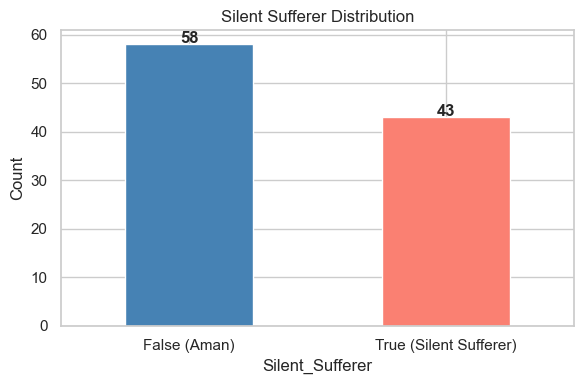

In [105]:
fig, ax = plt.subplots(figsize=(6, 4))

df['Silent_Sufferer'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Silent Sufferer Distribution')
ax.set_xticklabels(['False (Aman)', 'True (Silent Sufferer)'], rotation=0)
ax.set_ylabel('Count')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.3,
            str(int(p.get_height())), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [106]:
print(f"Class balance: {df['Silent_Sufferer'].value_counts().to_dict()}")
print(f"Rasio: {df['Silent_Sufferer'].mean():.1%} positif")

Class balance: {True: 58, False: 43}
Rasio: 57.4% positif


In [107]:
def simplify_cgpa(cgpa):
    if cgpa in ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99']:
        return 'Below 3.00'
    return cgpa

df['CGPA_grouped'] = df['CGPA'].apply(simplify_cgpa)
df

,Gender,Age,Year,CGPA,Marital,Treatment,Any_condition,Course,Course_group,Risk_Level,Silent_Sufferer,CGPA_grouped
0,Female,18.0,1,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High,True,3.00 - 3.49
1,Male,21.0,2,3.00 - 3.49,No,No,True,Islamic Education,Humanities & Education,Medium,True,3.00 - 3.49
2,Male,19.0,1,3.00 - 3.49,No,No,True,BIT,Engineering & Computing,High,True,3.00 - 3.49
3,Female,22.0,3,3.00 - 3.49,Yes,No,True,Law,Humanities & Education,Medium,True,3.00 - 3.49
4,Male,23.0,4,3.00 - 3.49,No,No,False,Mathematics,Natural & Health Sciences,Low,False,3.00 - 3.49
...,...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,1,3.50 - 4.00,No,No,True,BCS,Engineering & Computing,Medium,True,3.50 - 4.00
97,Male,18.0,2,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High,True,3.00 - 3.49
98,Female,19.0,3,3.50 - 4.00,Yes,No,True,Nursing,Natural & Health Sciences,High,True,3.50 - 4.00
99,Female,23.0,4,3.50 - 4.00,No,No,False,Islamic Education,Humanities & Education,Low,False,3.50 - 4.00


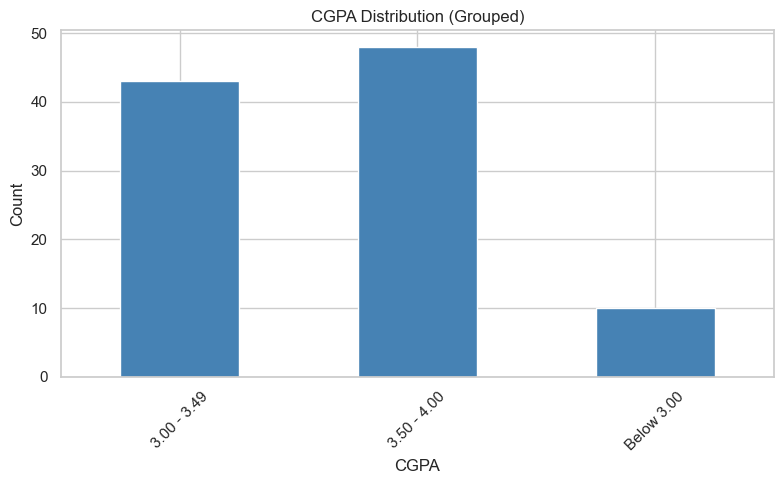

In [108]:
fig, ax = plt.subplots(figsize=(8, 5))

df['CGPA_grouped'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('CGPA Distribution (Grouped)')
ax.set_xlabel('CGPA')
ax.set_ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [109]:
for col in ['Marital', 'Treatment']:
    df[col] = df[col].map({'Yes': True, 'No': False})

In [110]:
df['Gender'] = df['Gender'].map({'Male': True, 'Female': False})

In [111]:
course_dummies = pd.get_dummies(df['Course_group'], prefix='CG', drop_first=True, dtype=int)
df = pd.concat([df, course_dummies], axis=1)

In [112]:
df['CGPA_grouped'].unique()

<StringArray>
['3.00 - 3.49', '3.50 - 4.00', 'Below 3.00']
Length: 3, dtype: str

In [113]:
df['CGPA_grouped'] = pd.Categorical(
    df['CGPA_grouped'],
    categories=['Below 3.00', '3.00 - 3.49', '3.50 - 4.00'],
    ordered=True
)
df['CGPA_grouped_encoded'] = df['CGPA_grouped'].cat.codes

In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Gender                        101 non-null    bool    
 1   Age                           101 non-null    float64 
 2   Year                          101 non-null    int64   
 3   CGPA                          101 non-null    str     
 4   Marital                       101 non-null    bool    
 5   Treatment                     101 non-null    bool    
 6   Any_condition                 101 non-null    bool    
 7   Course                        101 non-null    str     
 8   Course_group                  101 non-null    str     
 9   Risk_Level                    101 non-null    str     
 10  Silent_Sufferer               101 non-null    bool    
 11  CGPA_grouped                  101 non-null    category
 12  CG_Humanities & Education     101 non-null    int64   
 13  C

In [115]:
df.drop(columns=['CGPA', 'Course', 'Treatment', 'Any_condition',
                 'Risk_Level', 'CGPA_grouped', 'Course_group'], inplace=True)
df

,Gender,Age,Year,Marital,Silent_Sufferer,CG_Humanities & Education,CG_Natural & Health Sciences,CG_Social Sciences,CGPA_grouped_encoded
0,False,18.0,1,False,True,0,0,0,1
1,True,21.0,2,False,True,1,0,0,1
2,True,19.0,1,False,True,0,0,0,1
3,False,22.0,3,True,True,1,0,0,1
4,True,23.0,4,False,False,0,1,0,1
...,...,...,...,...,...,...,...,...,...
96,False,21.0,1,False,True,0,0,0,2
97,True,18.0,2,False,True,0,0,0,1
98,False,19.0,3,True,True,0,1,0,2
99,False,23.0,4,False,False,1,0,0,2


Dapat disimpulkan bahwa disini kami memiliki 6 fitur dasar (+ 3 OHE course) dan 1 target, yakni

**Fitur:**
- Gender
- Age
- Year
- Marital
- CGPA_grouped_encoded
- CG_Humanities & Education, CG_Natural & Health Sciences, CG_Social Sciences (OHE, drop_first)

**Target:**
- Silent_Sufferer

## Feature Correlation

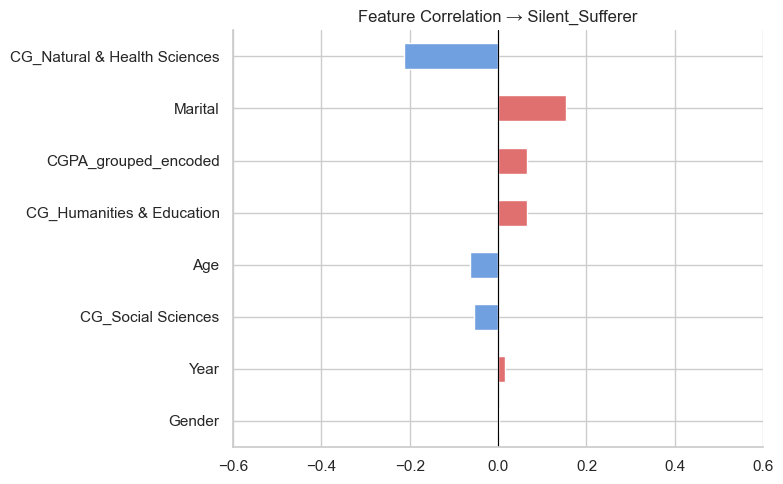

In [116]:
X = df.drop(columns=['Silent_Sufferer'])
y = df['Silent_Sufferer'].astype(int)

corrs = X.corrwith(y).sort_values(key=abs)
colors = ['#e07070' if v > 0 else '#70a0e0' for v in corrs]

fig, ax = plt.subplots(figsize=(8, 5))
corrs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation → Silent_Sufferer')
ax.set_xlim(-0.6, 0.6)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

terlihat fitur yang paling mempengaruhi adalah jurusan natural & health science, marital, dan cgpa. Yang lain memang dikit, tapi nanti semisal di tree based, masih bisa menjadi pertimbangan

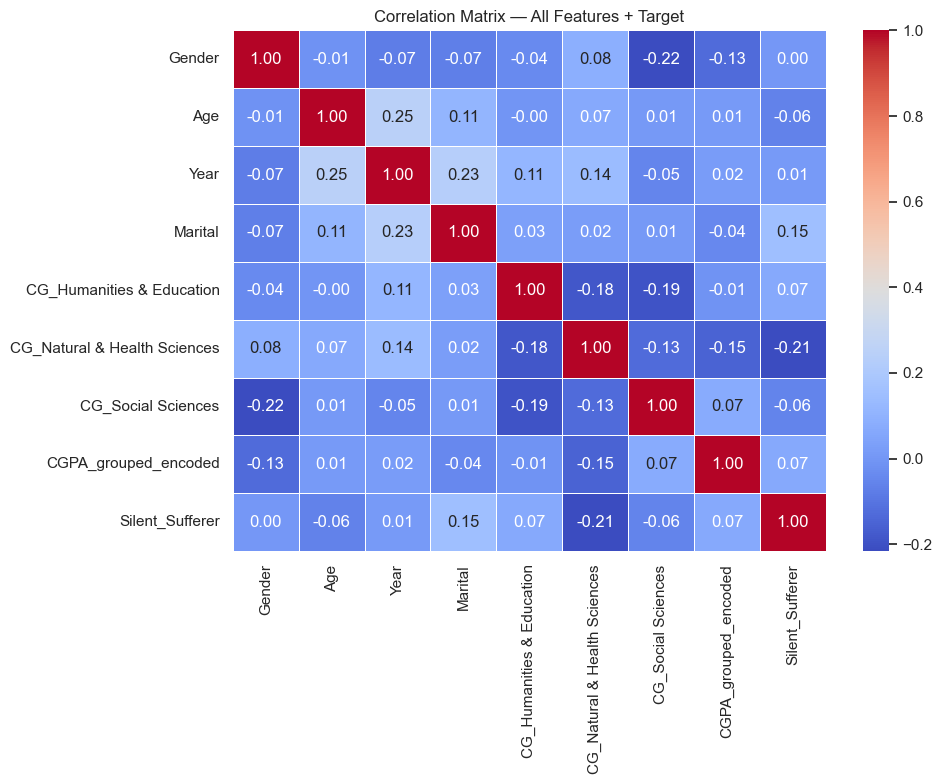

In [117]:
corr_matrix = pd.concat([X, y.rename('Silent_Sufferer')], axis=1).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — All Features + Target')
plt.tight_layout()
plt.show()

tidak ada korelasi absolut dari masing masing fitur

# 2. Modeling

In [118]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              make_scorer, fbeta_score, roc_auc_score,
                              precision_recall_curve, roc_curve, average_precision_score)
from xgboost import XGBClassifier

X = df.drop(columns=['Silent_Sufferer'])
y = df['Silent_Sufferer'].astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

SCORING = {
    'accuracy' : 'accuracy',
    'f1'       : 'f1',
    'f1_macro' : 'f1_macro',
    'f2'       : make_scorer(fbeta_score, beta=2),
    'roc_auc'  : 'roc_auc',
}
METRICS = ['Accuracy', 'F1', 'F1 Macro', 'F2', 'ROC-AUC']

print(f"Shape: {X.shape}")
print(f"Balance: {y.value_counts().to_dict()}")

Shape: (101, 8)
Balance: {1: 58, 0: 43}


In [119]:
def make_pipeline(name, model):
    needs_scaling = name in ['SVM', 'KNN', 'Logistic Regression']
    if needs_scaling:
        return Pipeline([('scaler', StandardScaler()), ('model', model)])
    return Pipeline([('model', model)])


def run_cv(models_dict, X, y, cv):
    rows = []
    for name, model in models_dict.items():
        pipe = make_pipeline(name, model)
        scores = cross_validate(pipe, X, y, cv=cv, scoring=SCORING)
        rows.append({
            'Model'    : name,
            'Accuracy' : scores['test_accuracy'].mean(),
            'F1'       : scores['test_f1'].mean(),
            'F1 Macro' : scores['test_f1_macro'].mean(),
            'F2'       : scores['test_f2'].mean(),
            'ROC-AUC'  : scores['test_roc_auc'].mean(),
        })
    return pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

In [120]:
models = {
    'Baseline'            : DummyClassifier(strategy='most_frequent'),
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=67),
    'SVM'                 : SVC(probability=True, class_weight='balanced', random_state=67),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=5,
                                                   class_weight='balanced', random_state=67),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=67),
    'XGBoost'             : XGBClassifier(eval_metric='logloss', use_label_encoder=False,
                                          scale_pos_weight=(y==0).sum()/(y==1).sum(),
                                          random_state=67),
}

In [121]:
cv_results = run_cv(models, X, y, cv=skf)

print("=== Cross-Validation Results (StratifiedKFold-5) ===")
print(cv_results[['Model'] + METRICS].round(3).to_string(index=False))

=== Cross-Validation Results (StratifiedKFold-5) ===
              Model  Accuracy    F1  F1 Macro    F2  ROC-AUC
      Random Forest     0.604 0.671     0.568 0.709    0.608
                SVM     0.653 0.725     0.622 0.772    0.604
                KNN     0.614 0.684     0.581 0.718    0.588
Logistic Regression     0.544 0.615     0.523 0.628    0.588
            XGBoost     0.543 0.569     0.526 0.568    0.567
  Gradient Boosting     0.525 0.608     0.488 0.635    0.528
           Baseline     0.574 0.729     0.365 0.871    0.500


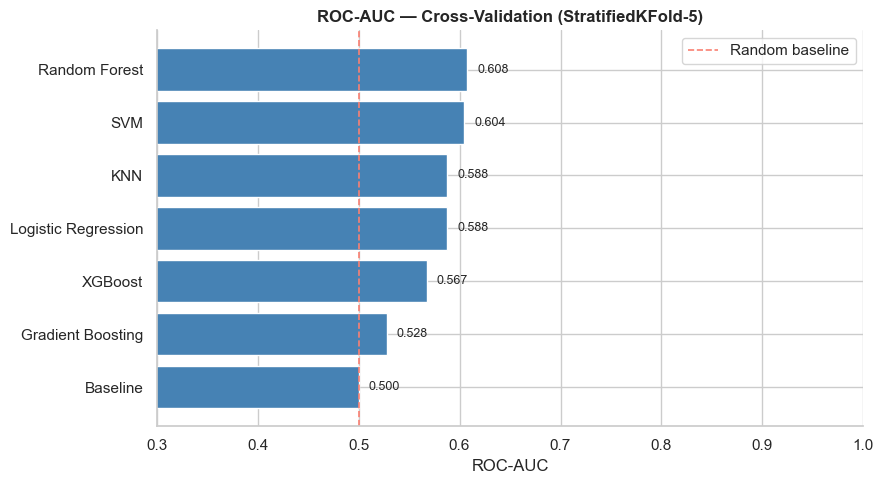

In [122]:
fig, ax = plt.subplots(figsize=(9, 5))

df_plot = cv_results.sort_values('ROC-AUC')
bars = ax.barh(df_plot['Model'], df_plot['ROC-AUC'], color='steelblue')
ax.axvline(0.5, color='salmon', linestyle='--', linewidth=1.2, label='Random baseline')
ax.set_xlim(0.3, 1.0)
ax.set_title('ROC-AUC — Cross-Validation (StratifiedKFold-5)', fontweight='bold')
ax.set_xlabel('ROC-AUC')
for bar, val in zip(bars, df_plot['ROC-AUC']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.legend()
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Kita akan ambil top 5 untuk maju ke hyperparameter tuning.

## 3. Hyperparameter Tuning
Grid search untuk 3 model terbaik.

In [123]:
from sklearn.model_selection import GridSearchCV

# ── Logistic Regression ──
lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=67))])
lr_grid = {'model__C': [0.01, 0.1, 1, 10, 100],
           'model__penalty': ['l1', 'l2'],
           'model__solver': ['liblinear']}
gs_lr = GridSearchCV(lr_pipe, lr_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
gs_lr.fit(X, y)
print(f"LR   best AUC={gs_lr.best_score_:.4f}  params={gs_lr.best_params_}")

# ── Random Forest --
rf_pipe = Pipeline([('model', RandomForestClassifier(class_weight='balanced', random_state=67))])
rf_grid = {'model__n_estimators': [100, 200, 300],
           'model__max_depth': [3, 5, 7, None],
           'model__min_samples_leaf': [1, 2, 3],
           'model__max_features': ['sqrt', 'log2']}
gs_rf = GridSearchCV(rf_pipe, rf_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X, y)
print(f"RF   best AUC={gs_rf.best_score_:.4f}  params={gs_rf.best_params_}")

# ── SVM ──
svm_pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', SVC(probability=True, class_weight='balanced', random_state=67))])
svm_grid = {'model__C': [0.1, 1, 10, 100],
            'model__kernel': ['rbf', 'linear'],
            'model__gamma': ['scale', 'auto', 0.01, 0.1]}
gs_svm = GridSearchCV(svm_pipe, svm_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
gs_svm.fit(X, y)
print(f"SVM  best AUC={gs_svm.best_score_:.4f}  params={gs_svm.best_params_}")

# ── KNN ──
knn_pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', KNeighborsClassifier())])
knn_grid = {'model__n_neighbors': [3, 5, 7, 9, 11],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan']}
gs_knn = GridSearchCV(knn_pipe, knn_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
gs_knn.fit(X, y)
print(f"KNN  best AUC={gs_knn.best_score_:.4f}  params={gs_knn.best_params_}")

# ── XGBoost ──
scale_pw = (y==0).sum() / (y==1).sum()
xgb_pipe = Pipeline([('model', XGBClassifier(eval_metric='logloss', use_label_encoder=False,
                                              scale_pos_weight=scale_pw, random_state=67))])
xgb_grid = {'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
             'model__max_depth': [2, 3, 4, 6],
             'model__n_estimators': [100, 200],
             'model__subsample': [0.8, 1.0],
             'model__colsample_bytree': [0.7, 1.0]}
gs_xgb = GridSearchCV(xgb_pipe, xgb_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
gs_xgb.fit(X, y)
print(f"XGB  best AUC={gs_xgb.best_score_:.4f}  params={gs_xgb.best_params_}")

LR   best AUC=0.5938  params={'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
RF   best AUC=0.6617  params={'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
SVM  best AUC=0.6044  params={'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
KNN  best AUC=0.6401  params={'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'distance'}
XGB  best AUC=0.6691  params={'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 1.0}


In [124]:
tuned_models = {
    'LR (tuned)' : gs_lr.best_estimator_,
    'RF (tuned)' : gs_rf.best_estimator_,
    'SVM (tuned)': gs_svm.best_estimator_,
    'KNN (tuned)': gs_knn.best_estimator_,  # ← tambah ini
    'XGB (tuned)': gs_xgb.best_estimator_,
}

rows = []
for name, pipe in tuned_models.items():
    scores = cross_validate(pipe, X, y, cv=skf, scoring=SCORING)
    rows.append({
        'Model'   : name,
        'Accuracy': scores['test_accuracy'].mean(),
        'F1'      : scores['test_f1'].mean(),
        'F1 Macro': scores['test_f1_macro'].mean(),
        'F2'      : scores['test_f2'].mean(),
        'ROC-AUC' : scores['test_roc_auc'].mean(),
    })

tuned_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("=== Tuned Models — Cross-Validation ===")
print(tuned_df[['Model'] + METRICS].round(3).to_string(index=False))

=== Tuned Models — Cross-Validation ===
      Model  Accuracy    F1  F1 Macro    F2  ROC-AUC
XGB (tuned)     0.654 0.701     0.634 0.713    0.669
 RF (tuned)     0.673 0.742     0.631 0.779    0.662
KNN (tuned)     0.623 0.674     0.601 0.673    0.640
SVM (tuned)     0.653 0.725     0.622 0.772    0.604
 LR (tuned)     0.554 0.626     0.531 0.642    0.594


## 4. Evaluasi Best Model
Pakai `cross_val_predict` agar bisa plot ROC, PR curve, dan confusion matrix yang proper dari CV — bukan dari single split yang noisy.

In [125]:
best_name = tuned_df.iloc[0]['Model']
best_pipe = tuned_models[best_name]
print(f"Best model: {best_name}")

y_pred  = cross_val_predict(best_pipe, X, y, cv=skf, method='predict')
y_proba = cross_val_predict(best_pipe, X, y, cv=skf, method='predict_proba')[:, 1]

print(f"\n=== Classification Report (default threshold=0.5) ===")
print(classification_report(y, y_pred, target_names=['Aman', 'Silent Sufferer']))
print(f"ROC-AUC: {roc_auc_score(y, y_proba):.4f}")

Best model: XGB (tuned)

=== Classification Report (default threshold=0.5) ===
                 precision    recall  f1-score   support

           Aman       0.60      0.56      0.58        43
Silent Sufferer       0.69      0.72      0.71        58

       accuracy                           0.65       101
      macro avg       0.64      0.64      0.64       101
   weighted avg       0.65      0.65      0.65       101

ROC-AUC: 0.6552


Model terbagus ternyata XGBoost, sesuai prediksi sih..

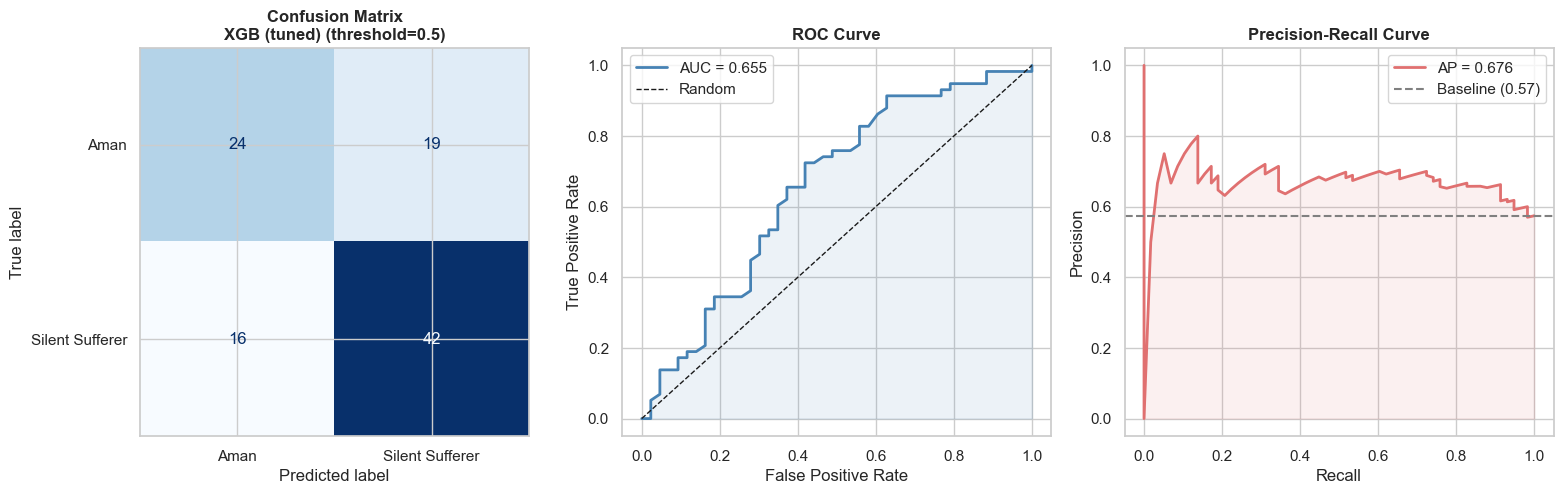

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
ax = axes[0]
ConfusionMatrixDisplay.from_predictions(y, y_pred,
    display_labels=['Aman', 'Silent Sufferer'],
    cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix\n{best_name} (threshold=0.5)', fontweight='bold')

# ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y, y_proba)
auc_val = roc_auc_score(y, y_proba)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_val:.3f}')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend()

# PR Curve
ax = axes[2]
prec, rec, _ = precision_recall_curve(y, y_proba)
ap = average_precision_score(y, y_proba)
ax.plot(rec, prec, color='#e07070', lw=2, label=f'AP = {ap:.3f}')
ax.fill_between(rec, prec, alpha=0.1, color='#e07070')
ax.axhline(y.mean(), color='gray', linestyle='--', label=f'Baseline ({y.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Threshold Optimization
Default threshold 0.5 tidak optimal. Untuk kasus **Silent Sufferer**, kita lebih mau tinggi recall
(lebih baik false alarm daripada miss mahasiswa yang butuh bantuan). Pakai F2 score sebagai kriteria
karena recall diberikan bobot 2x lebih besar dari precision.

In [127]:
prec_arr, rec_arr, thr_arr = precision_recall_curve(y, y_proba)
f2_arr = (1 + 2**2) * prec_arr * rec_arr / (2**2 * prec_arr + rec_arr + 1e-9)

best_idx = np.argmax(f2_arr[:-1])
best_thr = thr_arr[best_idx]

print(f"Optimal threshold (max F2): {best_thr:.3f}")
print(f"  @ thr={best_thr:.2f}: Precision={prec_arr[best_idx]:.3f}  Recall={rec_arr[best_idx]:.3f}  F2={f2_arr[best_idx]:.3f}")
print(f"  @ thr=0.50     : Precision={prec_arr[np.searchsorted(-thr_arr, -0.5)]:.3f}  Recall={rec_arr[np.searchsorted(-thr_arr, -0.5)]:.3f}")

Optimal threshold (max F2): 0.278
  @ thr=0.28: Precision=0.600  Recall=0.983  F2=0.872
  @ thr=0.50     : Precision=1.000  Recall=0.000


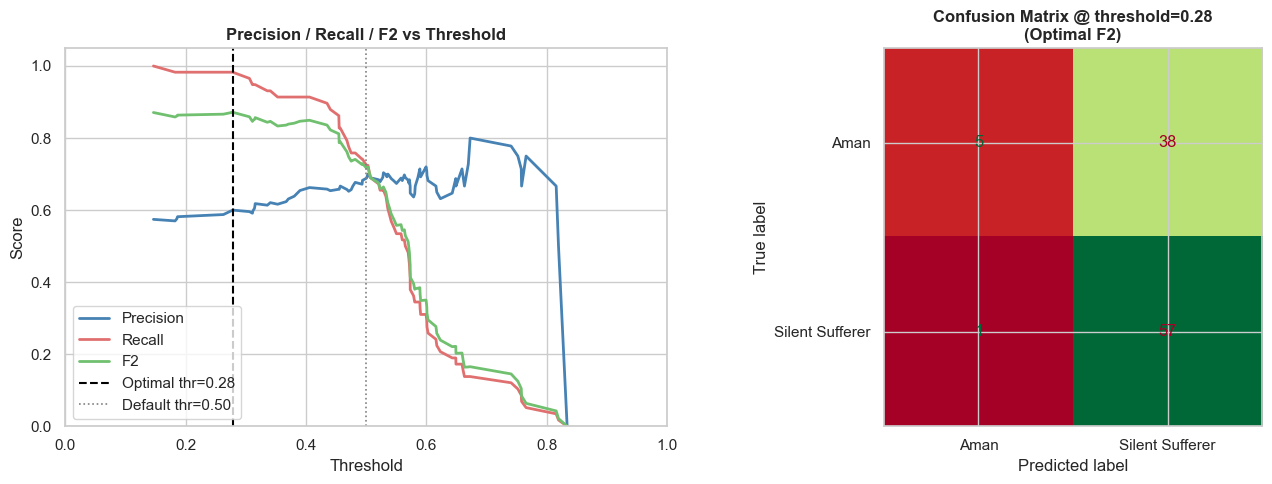

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thr_arr, prec_arr[:-1], label='Precision', color='steelblue', lw=2)
ax.plot(thr_arr, rec_arr[:-1],  label='Recall',    color='#e07070',   lw=2)
ax.plot(thr_arr, f2_arr[:-1],   label='F2',        color='#70c070',   lw=2)
ax.axvline(best_thr, color='black', linestyle='--', lw=1.5, label=f'Optimal thr={best_thr:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.2, label='Default thr=0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F2 vs Threshold', fontweight='bold')
ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

ax = axes[1]
y_opt = (y_proba >= best_thr).astype(int)
ConfusionMatrixDisplay.from_predictions(y, y_opt,
    display_labels=['Aman', 'Silent Sufferer'],
    cmap='RdYlGn', ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix @ threshold={best_thr:.2f}\n(Optimal F2)', fontweight='bold')

plt.tight_layout()
plt.show()

In [129]:
y_opt = (y_proba >= best_thr).astype(int)
print(f"=== Final Report @ Optimal Threshold ({best_thr:.2f}) ===")
print(classification_report(y, y_opt, target_names=['Aman', 'Silent Sufferer']))
print(f"ROC-AUC : {roc_auc_score(y, y_proba):.4f}")
print(f"Avg Prec: {average_precision_score(y, y_proba):.4f}")

=== Final Report @ Optimal Threshold (0.28) ===
                 precision    recall  f1-score   support

           Aman       0.83      0.12      0.20        43
Silent Sufferer       0.60      0.98      0.75        58

       accuracy                           0.61       101
      macro avg       0.72      0.55      0.47       101
   weighted avg       0.70      0.61      0.51       101

ROC-AUC : 0.6552
Avg Prec: 0.6764


## 6. Feature Importance
Fit model ke full dataset untuk lihat feature mana yang paling berkontribusi.

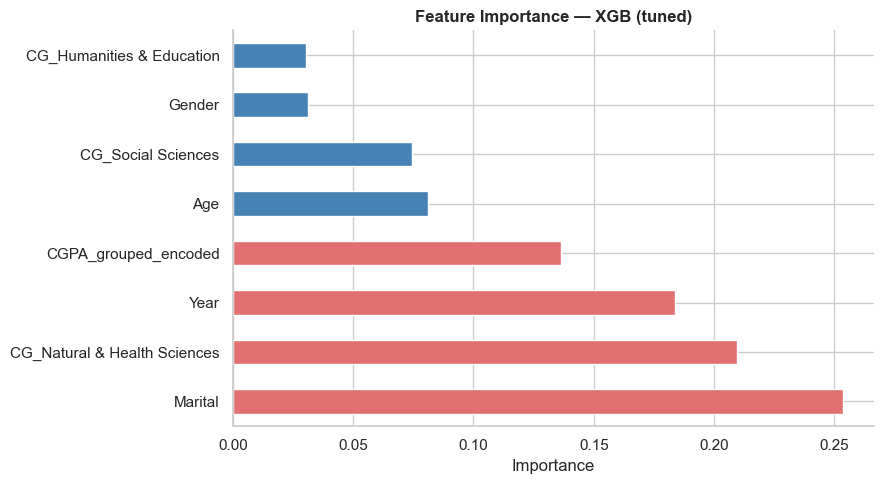


Feature importances:
Marital                         0.2538
CG_Natural & Health Sciences    0.2094
Year                            0.1838
CGPA_grouped_encoded            0.1363
Age                             0.0809
CG_Social Sciences              0.0743
Gender                          0.0311
CG_Humanities & Education       0.0303


In [130]:
best_pipe.fit(X, y)
clf = best_pipe.named_steps['model']

if hasattr(clf, 'feature_importances_'):
    imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#e07070' if v >= imp.median() else 'steelblue' for v in imp]
    imp.sort_values().plot(kind='barh', ax=ax, color=list(reversed(colors)))
    ax.set_title(f'Feature Importance — {best_name}', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

    print("\nFeature importances:")
    print(imp.round(4).to_string())
elif hasattr(clf, 'coef_'):
    imp = pd.Series(np.abs(clf.coef_[0]), index=X.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 5))
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature Importance (|coef|) — {best_name}', fontweight='bold')
    ax.set_xlabel('|Coefficient|')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

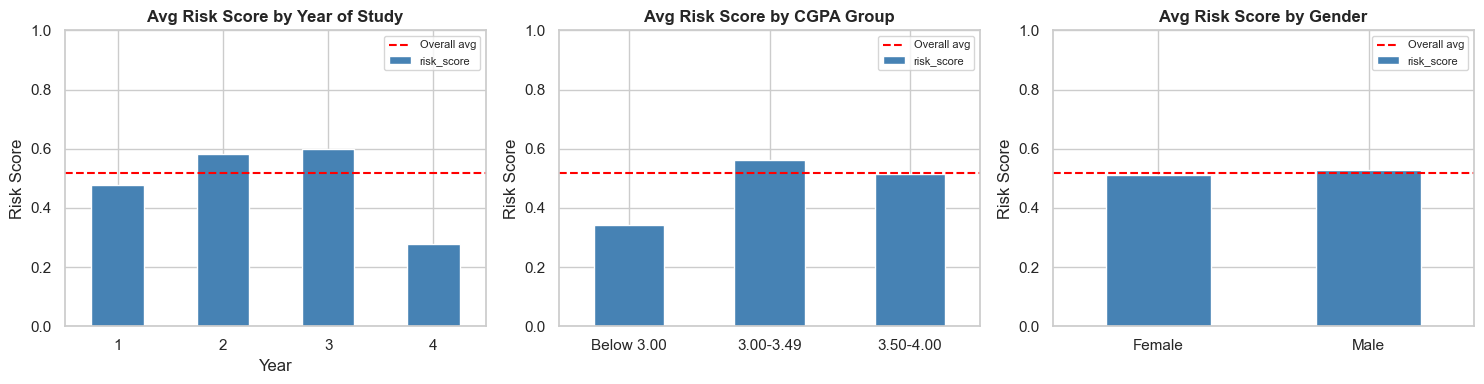

In [131]:
df_risk = X.copy()
df_risk['risk_score'] = y_proba
df_risk['actual']     = y.values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, label) in zip(axes, [('Year','Year of Study'), ('CGPA_grouped_encoded','CGPA Group'), ('Gender','Gender')]):
    avg = df_risk.groupby(col)['risk_score'].mean()
    if col == 'Gender':
        avg.index = ['Female', 'Male']
    elif col == 'CGPA_grouped_encoded':
        avg.index = ['Below 3.00', '3.00-3.49', '3.50-4.00']
    avg.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', rot=0)
    ax.axhline(y_proba.mean(), color='red', linestyle='--', lw=1.5, label='Overall avg')
    ax.set_title(f'Avg Risk Score by {label}', fontweight='bold')
    ax.set_ylabel('Risk Score'); ax.set_ylim(0, 1); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Summary

In [132]:
print("=" * 55)
print("  RINGKASAN HASIL")
print("=" * 55)
print(f"  Target         : Silent Sufferer (MH untreated)")
print(f"  Dataset        : {len(X)} baris, {X.shape[1]} fitur")
print(f"  Class balance  : {y.sum()} positif / {(y==0).sum()} negatif ({y.mean():.1%})")
print(f"  Best model     : {best_name}")
print(f"  ROC-AUC (CV)   : {roc_auc_score(y, y_proba):.4f}")
print(f"  Optimal thr    : {best_thr:.3f} (maximize F2)")
print()
from sklearn.metrics import f1_score, recall_score, precision_score
print(f"  @ threshold 0.5:")
print(f"    Precision = {precision_score(y, y_pred):.3f}")
print(f"    Recall    = {recall_score(y, y_pred):.3f}")
print(f"    F1        = {f1_score(y, y_pred):.3f}")
print()
y_opt = (y_proba >= best_thr).astype(int)
print(f"  @ threshold {best_thr:.2f} (optimal F2):")
print(f"    Precision = {precision_score(y, y_opt):.3f}")
print(f"    Recall    = {recall_score(y, y_opt):.3f}")
print(f"    F1        = {f1_score(y, y_opt):.3f}")
print()
print("  Top features (jika tree-based):")
if hasattr(best_pipe.named_steps['model'], 'feature_importances_'):
    imp = pd.Series(best_pipe.named_steps['model'].feature_importances_, index=X.columns)
    for feat, val in imp.sort_values(ascending=False).head(3).items():
        print(f"    {feat:<30} {val:.4f}")

  RINGKASAN HASIL
  Target         : Silent Sufferer (MH untreated)
  Dataset        : 101 baris, 8 fitur
  Class balance  : 58 positif / 43 negatif (57.4%)
  Best model     : XGB (tuned)
  ROC-AUC (CV)   : 0.6552
  Optimal thr    : 0.278 (maximize F2)

  @ threshold 0.5:
    Precision = 0.689
    Recall    = 0.724
    F1        = 0.706

  @ threshold 0.28 (optimal F2):
    Precision = 0.600
    Recall    = 0.983
    F1        = 0.745

  Top features (jika tree-based):
    Marital                        0.2538
    CG_Natural & Health Sciences   0.2094
    Year                           0.1838


Hasil akhirnya adalah kita menggunakan model XGBoost dengan hyperparameter tuning dengan threshold 0.28. Terlihat kecil, tapi memang itu yang kita butuhkan untuk mendapatkan recall dan F2-score yang baik. F2-score yang tinggi mengindikasikan rendahnya False Negative yang kita tidak inginkan.